In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder

# Upload data
features = pd.read_excel('镍基高温合金微观数据集合.xlsx')
label1 = np.array(features['评价'])
features = features.drop(['强化相', '固态温度', '液态温度', '凝固区间温度', '强化相溶解温度', '加工窗口', '错配度', 'TCP', '评价'], axis=1)

# One-hot encode categorical features
features = pd.get_dummies(features)

# Saving feature names for later use
feature_list = list(features.columns)

# Convert to numpy array
features = np.array(features)

# Encode the labels
label_encoder = LabelEncoder()
label1_encoded = label_encoder.fit_transform(label1)

# Splitting the data into train and test sets
SEED = 26
train_features1, test_features1, train_labels1, test_labels1 = train_test_split(features, label1_encoded,
                                                                                test_size=0.25,
                                                                                random_state=SEED,
                                                                                stratify=label1_encoded)

# MLP classifier
Model1 = MLPClassifier(random_state=SEED)

# Model training
Model1.fit(train_features1, train_labels1)

# Model prediction
predictions1 = Model1.predict(test_features1)

# Decode the predicted labels
predictions1 = label_encoder.inverse_transform(predictions1)

# Decode the test labels
test_labels1 = label_encoder.inverse_transform(test_labels1)

# Evaluation
target_names = ['Unacceptable', 'Very Good']

def evaluate(test_labels, predictions):
    cm = confusion_matrix(test_labels, predictions, labels=target_names)
    report = classification_report(test_labels, predictions, labels=target_names, output_dict=True)
    report_df = pd.DataFrame(report)
    avg = report_df['weighted avg']
    cm_df = pd.DataFrame(cm)
    report_df = pd.concat([report_df, cm_df])
    return report_df, avg, cm

report1, avg1, cm1 = evaluate(test_labels1, predictions1)

# Saving the output to an Excel file
final_output = pd.DataFrame()
final_output.loc[:, 1] = avg1
final_output = final_output.T
final_output.to_excel(r'final_output_seed_MLP_1.xlsx', index=True)
final_output

/Users/macbookpro/opt/anaconda3/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,precision,recall,f1-score,support
1,0.908497,0.882353,0.88317,34.0


In [2]:
# Step 1: Load the new data
new_data = pd.read_excel('weiguan的副本.xlsx')

# Step 3: One-hot encode categorical features and convert to numpy array
new_data = pd.get_dummies(new_data)
new_data = np.array(new_data)

# Step 4: Use the trained random forest model to predict the class labels
predictions_new_data = Model1.predict(new_data)

# Step 5: Output the classification results
classification_results = pd.DataFrame({'Classification': predictions_new_data})
classification_results.to_excel('classification_results_bpnn.xlsx', index=False)
classification_results

,Classification
0,0
1,1
2,0
3,1
4,1
5,0
6,0
7,1
8,0
9,0


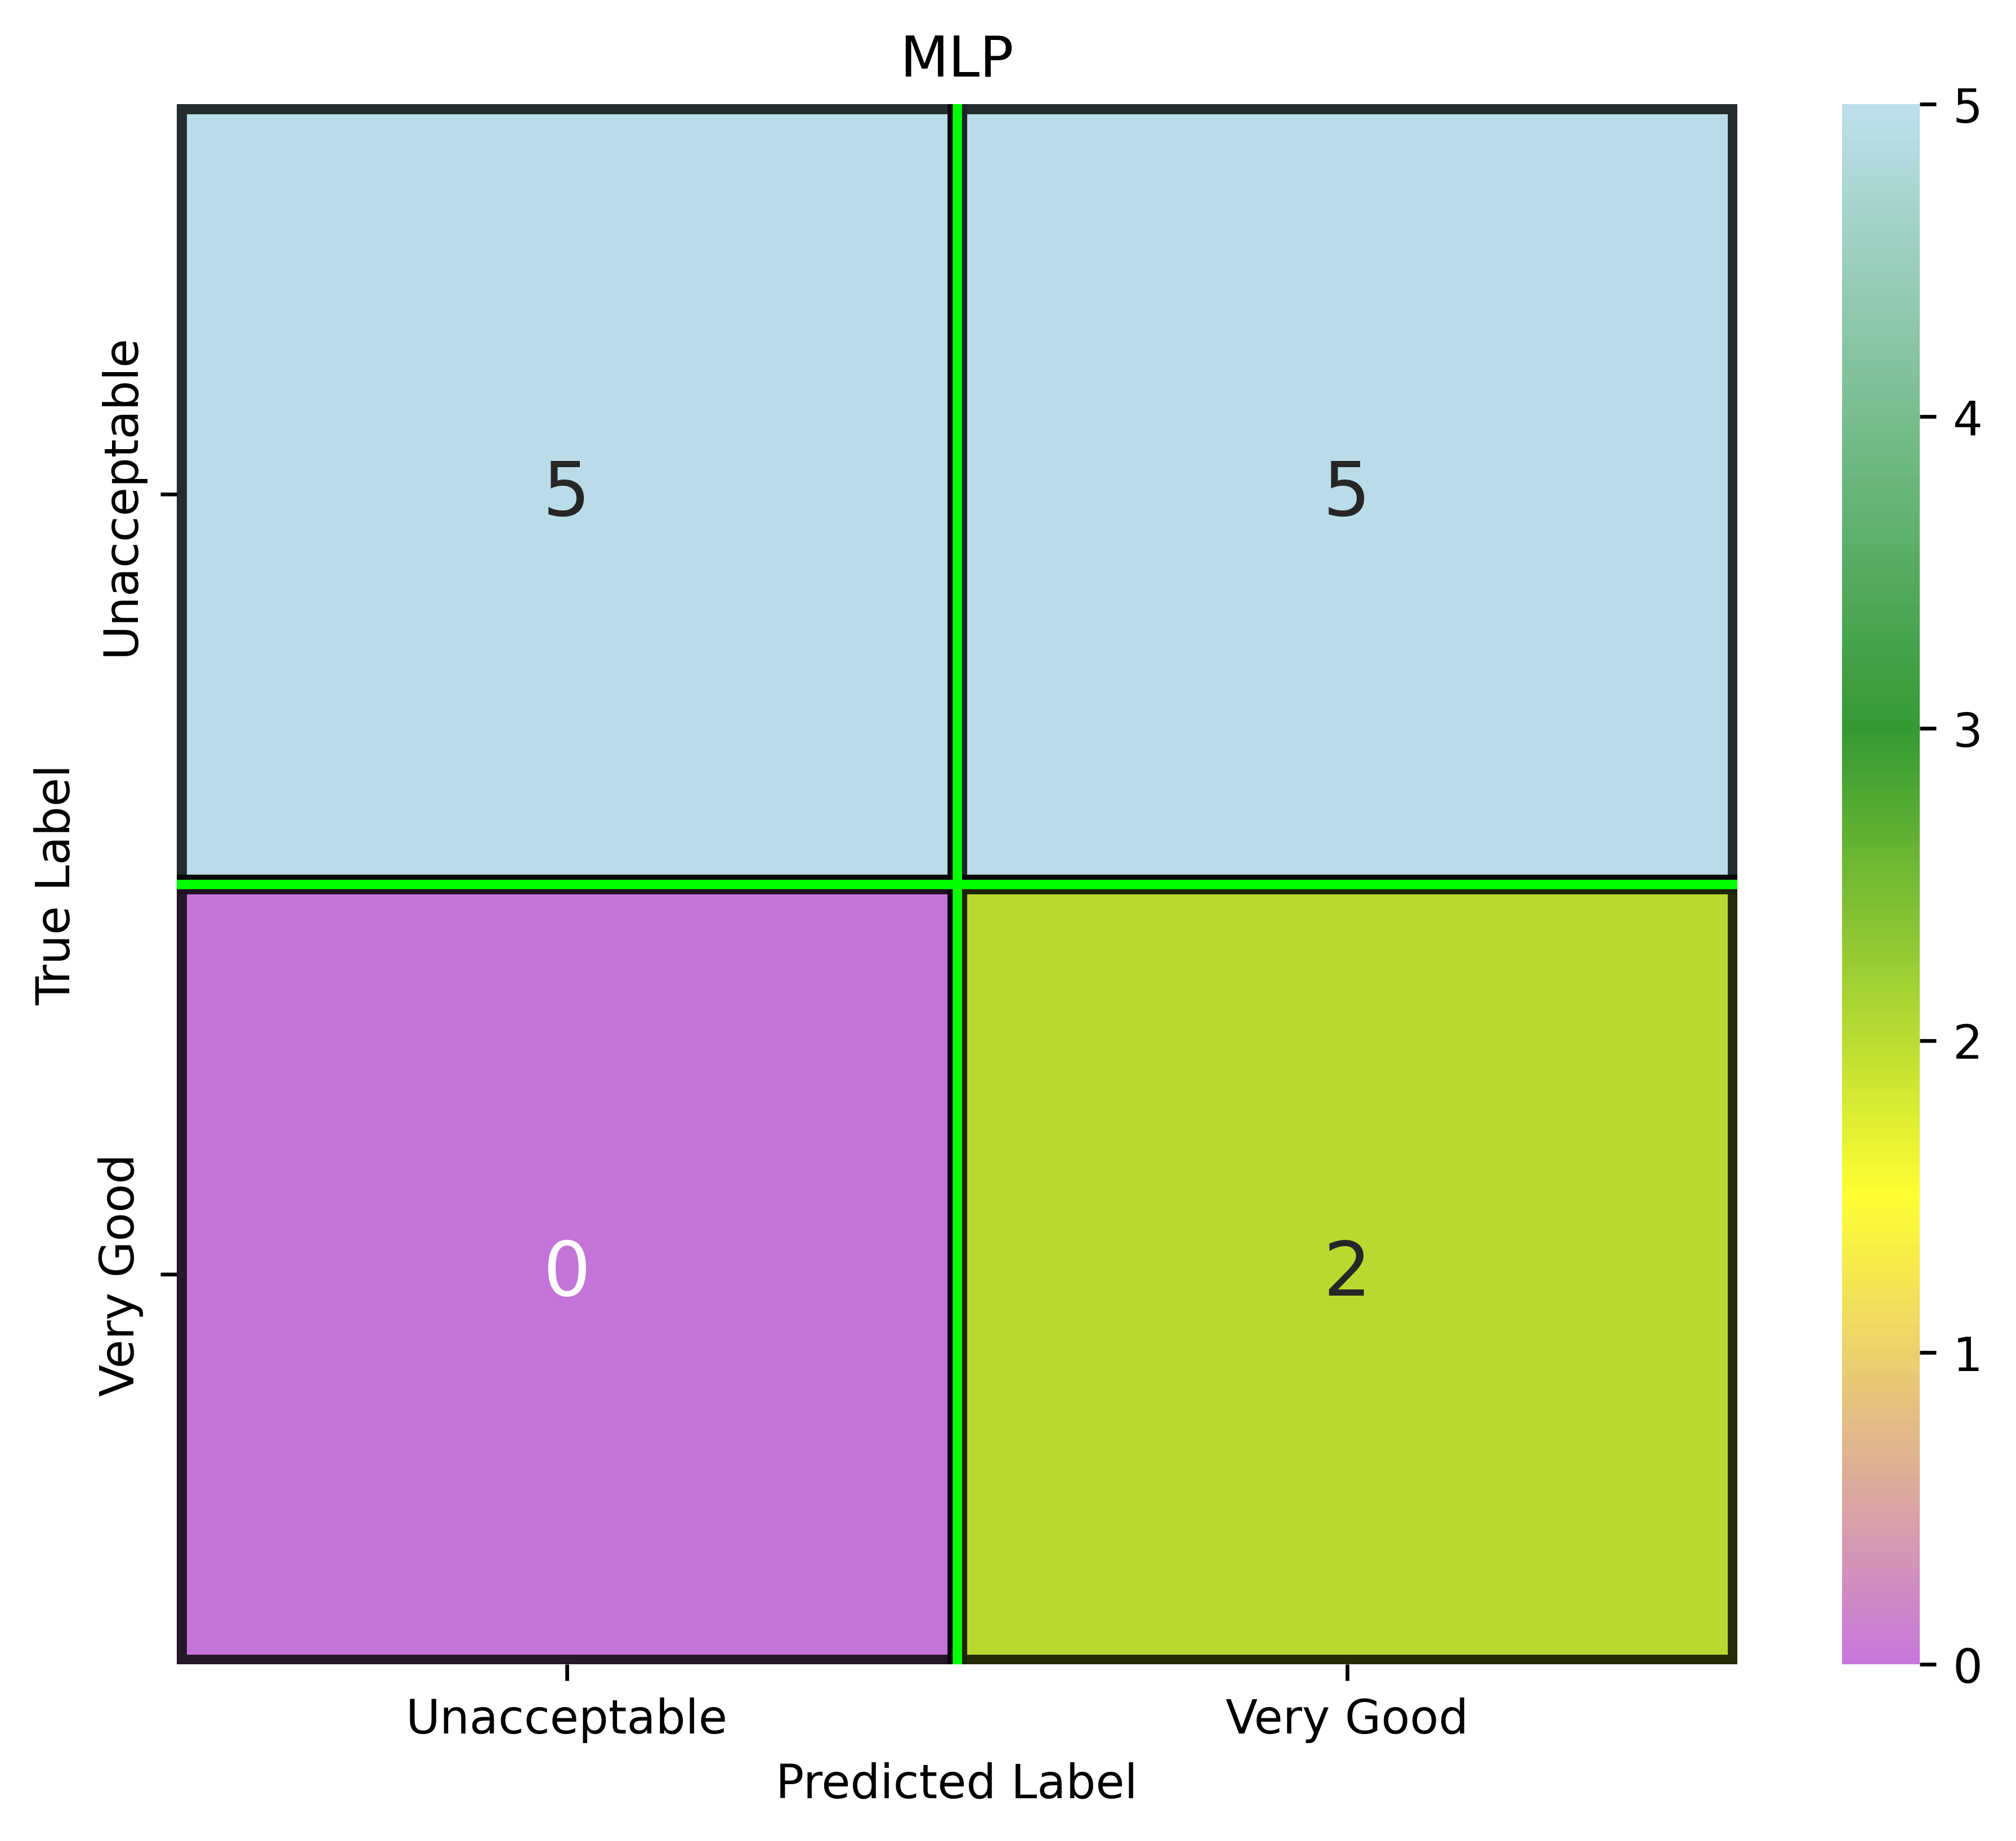

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Step 1: Load the new data
new_data = pd.read_excel('新数据验证.xlsx')
new_data_1 = pd.read_excel('classification_results_bpnn.xlsx')
# Step 2: Replace this line with loading your predictions for new data
predictions_new_data = np.array(new_data_1['Classification'])  # Replace '预测' with the actual column name

# Step 3: Define your target class names
target_names = ['Unacceptable', 'Very Good']

# Step 4: Get the true labels from the new data
true_labels = np.array(new_data['评价'])

# Step 5: Map class labels to colors
color_map = {'Unacceptable': 'green', 'Very Good': 'blue'}
true_colors = [color_map[label] for label in true_labels]
predicted_colors = ['white' if label == 0 else color_map[label] for label in predictions_new_data]

# Create a confusion matrix format
confusion_matrix = [[0, 0], [0, 0]]
for true_color, predicted_color in zip(true_colors, predicted_colors):
    if true_color == 'blue' and predicted_color == 'blue':
        confusion_matrix[1][1] += 1
    elif true_color == 'green' and predicted_color == 'green':
        confusion_matrix[0][0] += 1
    else:
        confusion_matrix[0][1] += 1

# Create a custom colormap with a gradient of the specified colors
colors = [
    (0.0, 'mediumorchid'),
    (0.3, 'yellow'),
    (0.6, 'green'),
    (1.0, 'lightblue')
]
cmap = LinearSegmentedColormap.from_list("Custom", colors)

# Create a heatmap of the confusion matrix with the custom colormap
fig, ax = plt.subplots(figsize=(8, 6), dpi=600)
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap=cmap, cbar=True,
            xticklabels=target_names, yticklabels=target_names, ax=ax,
            linewidths=4, linecolor='black', square=True, alpha=0.8, annot_kws={"size": 16})

# Add vertical and horizontal lines to separate the blocks
n_classes = len(target_names)
for i in range(1, n_classes):
    ax.axhline(i, color='#00FF00', linewidth=2)
    ax.axvline(i, color='#00FF00', linewidth=2)

# Set background gradient color
ax.set_facecolor('#f0f0f0')

plt.title('MLP')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()